In [21]:
# Tout d'abord on import les librairies nécessaires

import pandas as pd
import numpy as np
import mne
import sklearn 
import matplotlib.pyplot as plt
import os 
import glob
import random

# Dossier qui contient tous les patients (sub-001, sub-002, etc.)
DOSSIER_DATA = r"C:\Users\Alina\Desktop\AMU\DESU Data science\Projet\Data"

In [22]:
# Ici on définit quelques fonctions pour manipuler les fichiers EEG et ECG des patients.
# ECG est le coeur pour les prédictions, mais il est stocké dans un dossier séparé du dossier EEG. On va donc relier les deux.

def dossier_eeg(patient):
    """Donne le chemin du dossier eeg d'un patient. Exemple : dossier_eeg("sub-100")"""
    return os.path.join(DOSSIER_DATA, patient, "ses-01", "eeg")


def liste_crises(patient):
    """Lit tous les fichiers .tsv du patient et renvoie un tableau de TOUTES ses crises."""
    fichiers_tsv = sorted(glob.glob(os.path.join(dossier_eeg(patient), "*_events.tsv")))

    toutes_les_crises = []
    for fichier in fichiers_tsv:
        tableau = pd.read_csv(fichier, sep="\t")
        crises = tableau[tableau["eventType"].str.startswith("sz", na=False)]
        for _, ligne in crises.iterrows():
            toutes_les_crises.append({
                "fichier_tsv": fichier,
                "debut": ligne["onset"],
                "duree": ligne["duration"],
                "type": ligne["eventType"],
            })
    return pd.DataFrame(toutes_les_crises)


def fichier_ecg(fichier_tsv):
    """À partir du .tsv (dossier eeg), trouve le fichier ECG de la même run (dossier ecg)."""
    chemin = fichier_tsv.replace(os.sep + "eeg" + os.sep, os.sep + "ecg" + os.sep)
    return chemin.replace("_events.tsv", "_ecg.edf")


def charger_ecg(chemin_ecg, debut, fin):
    """Charge seulement le morceau d'ECG entre 'debut' et 'fin' (en secondes)."""
    raw = mne.io.read_raw_edf(chemin_ecg, preload=False, verbose="ERROR")
    canal = raw.ch_names[0]                  # le fichier ECG n'a qu'un canal : "ECG SD"
    debut = max(0, debut)                    # pas avant le début de l'enregistrement
    fin = min(raw.times[-1], fin)            # pas après la fin
    morceau = raw.copy().pick([canal]).crop(tmin=debut, tmax=fin).load_data()
    signal, temps = morceau[:]
    return temps + debut, signal[0], canal   # on remet le vrai temps


def tracer_crise(patient, numero=0, marge=30):
    """Trace l'ECG autour d'une crise du patient, avec la crise en rouge."""
    crises = liste_crises(patient)
    if len(crises) == 0:
        print("Aucune crise chez", patient)
        return
    if numero >= len(crises):
        print(f"{patient} n'a que {len(crises)} crise(s). Choisissez un numéro entre 0 et {len(crises)-1}.")
        return

    crise = crises.iloc[numero]
    chemin = fichier_ecg(crise["fichier_tsv"])
    if not os.path.exists(chemin):
        print("Pas de fichier ECG pour cette run :", chemin)
        return

    debut, duree = crise["debut"], crise["duree"]
    temps, signal, canal = charger_ecg(chemin, debut - marge, debut + duree + marge)

    plt.figure(figsize=(14, 4))
    plt.plot(temps, signal, linewidth=0.6, color="black")
    plt.axvspan(debut, debut + duree, color="red", alpha=0.3, label="Crise")
    plt.xlabel("Temps (s)")
    plt.ylabel(canal)
    plt.title(f"{patient} — crise {numero+1}/{len(crises)} — {os.path.basename(chemin)}")
    plt.legend()
    plt.show()

Nombre de runs trouvées : 13
Run : sub-100_ses-01_task-szMonitoring_run-03_eeg.edf
Crise : début 2628.0 s, durée 172.0 s
Fichier ECG : C:\Users\Alina\Desktop\AMU\DESU Data science\Projet\Data\sub-100\ses-01\ecg\sub-100_ses-01_task-szMonitoring_run-03_ecg.edf
Existe ? True
Canaux : ['ECG SD']
Reading 0 ... 59392  =      0.000 ...   232.000 secs...


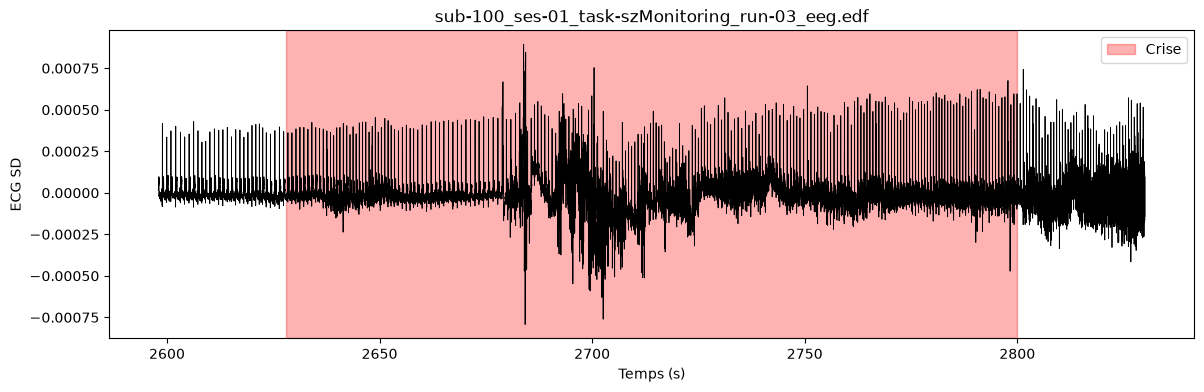

In [20]:
# 1. Dossier du patient (mettez le chemin COMPLET)
PATIENT_DIR = r"C:\Users\Alina\Desktop\AMU\DESU Data science\Projet\Data\sub-100\ses-01\eeg"
PAD = 30   # secondes affichées avant et après la crise

# 2. Chercher une run qui contient une crise
tsv_files = sorted(glob.glob(os.path.join(PATIENT_DIR, "*_events.tsv")))
print("Nombre de runs trouvées :", len(tsv_files))

crise_trouvee = False
for tsv in tsv_files:
    df = pd.read_csv(tsv, sep="\t")
    crises = df[df["eventType"].str.startswith("sz")]   # les crises commencent par "sz"
    if len(crises) > 0:
        onset = crises["onset"].iloc[0]        # début de la 1re crise (s)
        duration = crises["duration"].iloc[0]  # durée de la crise (s)
        edf = tsv.replace("_events.tsv", "_eeg.edf")
        crise_trouvee = True
        break

if not crise_trouvee:
    print("Aucune crise chez ce patient.")
else:
    print("Run :", os.path.basename(edf))
    print(f"Crise : début {onset:.1f} s, durée {duration:.1f} s")

    # 3. Trouver le fichier ECG de la même run (dans le dossier "ecg")
    ecg_edf = edf.replace(os.sep + "eeg" + os.sep, os.sep + "ecg" + os.sep).replace("_eeg.edf", "_ecg.edf")
    print("Fichier ECG :", ecg_edf)
    print("Existe ?", os.path.exists(ecg_edf))

    raw = mne.io.read_raw_edf(ecg_edf, preload=False, verbose="ERROR")
    print("Canaux :", raw.ch_names)

    # 4. Prendre le premier canal du fichier ECG
    ecg_ch = raw.ch_names[0]

    # 4. Trouver le canal ECG
    ecg_ch = [c for c in raw.ch_names if "ecg" in c.lower()][0]

    # 5. Charger seulement l'ECG autour de la crise
    start = max(0, onset - PAD)
    stop = min(raw.times[-1], onset + duration + PAD)
    seg = raw.copy().pick([ecg_ch]).crop(tmin=start, tmax=stop).load_data()
    signal, times = seg[:]
    times = times + start      # remettre le temps réel de l'enregistrement

    # 6. Tracer
    plt.figure(figsize=(14, 4))
    plt.plot(times, signal[0], linewidth=0.6, color="black")
    plt.axvspan(onset, onset + duration, color="red", alpha=0.3, label="Crise")
    plt.xlabel("Temps (s)")
    plt.ylabel(ecg_ch)
    plt.title(os.path.basename(edf))
    plt.legend()
    plt.show()